# Predict Math Score

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error,root_mean_squared_error
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [3]:
df=pd.read_csv("data/stud.csv")

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
X=df.drop('math_score',axis=1)

In [6]:
Y=df['math_score']

In [7]:
num_feature=X.select_dtypes(exclude='object').columns
cat_feature=X.select_dtypes(include='object').columns

C:\Users\bhand\AppData\Local\Temp\ipykernel_30276\694665136.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_feature=X.select_dtypes(include='object').columns


In [8]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

ohe=OneHotEncoder()
num_scaler=StandardScaler()

preprocess=ColumnTransformer([
    ("OneHotEncoder",ohe,cat_feature),
    ("StandardScaler",num_scaler,num_feature)
])

In [9]:
X=preprocess.fit_transform(X)

In [10]:
X.shape

(1000, 19)

In [11]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [12]:
x_train.shape,x_test.shape

((800, 19), (200, 19))

In [13]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    r2_square=r2_score(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=root_mean_squared_error(true,predicted)
    return mae,r2_square,mse,rmse

In [14]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "Rigid":Ridge(),
    "Decision Tree":DecisionTreeRegressor(),
    "K NearestNeighbors":KNeighborsRegressor(),
    "Support Vector Regressor":SVR(),
    "CatBoosting Regresssor":CatBoostRegressor(verbose=False),
    "XGBoost":XGBRegressor(),
    "AdaBoost":AdaBoostRegressor()
}

model_list=[]
r2_list=[]
li=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)

    y_predict=model.predict(x_test)

    mae,r2_square,mse,rmse=evaluate_model(y_test,y_predict)

    model_list.append(list(models.keys())[i])
    print()
    print("Preformance of: ",list(models.keys())[i])
    print(f"Mean Square Error is: {mse:.4f}")
    print(f"Mean Absolute Error is: {mae:.4f}")
    print(f"Root Mean Square Error is: {rmse:.4f}")
    print(f"R Square Error is: {r2_square:.4f}")

    r2_list.append(r2_square)
    


Preformance of:  Linear Regression
Mean Square Error is: 29.0952
Mean Absolute Error is: 4.2148
Root Mean Square Error is: 5.3940
R Square Error is: 0.8804

Preformance of:  Lasso
Mean Square Error is: 42.5064
Mean Absolute Error is: 5.1579
Root Mean Square Error is: 6.5197
R Square Error is: 0.8253

Preformance of:  Rigid
Mean Square Error is: 29.0563
Mean Absolute Error is: 4.2111
Root Mean Square Error is: 5.3904
R Square Error is: 0.8806

Preformance of:  Decision Tree
Mean Square Error is: 65.4350
Mean Absolute Error is: 6.3750
Root Mean Square Error is: 8.0892
R Square Error is: 0.7311

Preformance of:  K NearestNeighbors
Mean Square Error is: 52.6066
Mean Absolute Error is: 5.6210
Root Mean Square Error is: 7.2530
R Square Error is: 0.7838

Preformance of:  Support Vector Regressor
Mean Square Error is: 66.0420
Mean Absolute Error is: 5.4015
Root Mean Square Error is: 8.1266
R Square Error is: 0.7286

Preformance of:  CatBoosting Regresssor
Mean Square Error is: 36.1037
Mean Ab

In [15]:
score_list=list(zip(model_list,r2_list))

In [16]:
score_list

[('Linear Regression', 0.8804332983749565),
 ('Lasso', 0.8253197323627852),
 ('Rigid', 0.8805931485028737),
 ('Decision Tree', 0.73109464022119),
 ('K NearestNeighbors', 0.7838129945787431),
 ('Support Vector Regressor', 0.7286001513223705),
 ('CatBoosting Regresssor', 0.8516318920747058),
 ('XGBoost', 0.8277965784072876),
 ('AdaBoost', 0.8497269590421741)]

In [17]:
score_list=pd.DataFrame(score_list,columns=["Model","R2_Score"]).sort_values(by=["R2_Score"],ascending=False)

In [18]:
score_list

,Model,R2_Score
2,Rigid,0.880593
0,Linear Regression,0.880433
6,CatBoosting Regresssor,0.851632
8,AdaBoost,0.849727
7,XGBoost,0.827797
1,Lasso,0.825320
4,K NearestNeighbors,0.783813
3,Decision Tree,0.731095
5,Support Vector Regressor,0.728600


In [19]:
lnr=LinearRegression(fit_intercept=True)
lnr=lnr.fit(x_train,y_train)
y_pred=lnr.predict(x_test)
score=r2_score(y_test,y_pred)*100
print("Accuracy of model is: %2.f" %score)

Accuracy of model is: 88


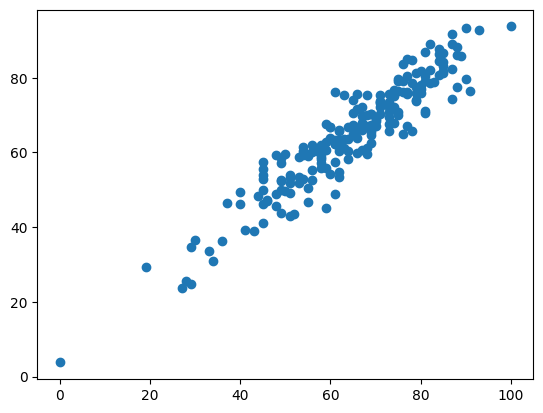

In [20]:
plt.scatter(y_test,y_pred)